# Downloading data

In [1]:
!wget  https://github.com/marcin119a/data/raw/refs/heads/main/data_gsn.zip
!unzip data_gsn.zip &> /dev/null
!rm data_gsn.zip

--2025-11-25 18:21:56--  https://github.com/marcin119a/data/raw/refs/heads/main/data_gsn.zip
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/marcin119a/data/refs/heads/main/data_gsn.zip [following]
--2025-11-25 18:21:57--  https://raw.githubusercontent.com/marcin119a/data/refs/heads/main/data_gsn.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5544261 (5.3M) [application/zip]
Saving to: ‘data_gsn.zip’

data_gsn.zip        100%[===================>]   5.29M  --.-KB/s    in 0.05s   

2025-11-25 18:21:57 (99.4 MB/s) - ‘data_gsn.zip’ saved [5544261/5544261]



# Imports

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision.io import read_image
from torch.utils.data import TensorDataset, DataLoader, Dataset
import torch.nn.functional as F
from itertools import combinations
from sklearn.metrics import f1_score, mean_squared_error, mean_absolute_error, confusion_matrix
from torch.utils.data import random_split
import matplotlib.pyplot as plt
import time
import seaborn as sns

# EDA

In [3]:
df = pd.read_csv("data/labels.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   name     10000 non-null  object
 1   squares  10000 non-null  int64 
 2   circles  10000 non-null  int64 
 3   up       10000 non-null  int64 
 4   right    10000 non-null  int64 
 5   down     10000 non-null  int64 
 6   left     10000 non-null  int64 
dtypes: int64(6), object(1)
memory usage: 547.0+ KB


In [4]:
df.describe()

,squares,circles,up,right,down,left
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.65740,1.714900,1.653000,1.677000,1.685700,1.612000
std,2.62909,2.656073,2.619557,2.627539,2.641101,2.574979
min,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3.00000,3.000000,3.000000,3.000000,3.000000,3.000000
max,8.00000,8.000000,8.000000,8.000000,8.000000,8.000000


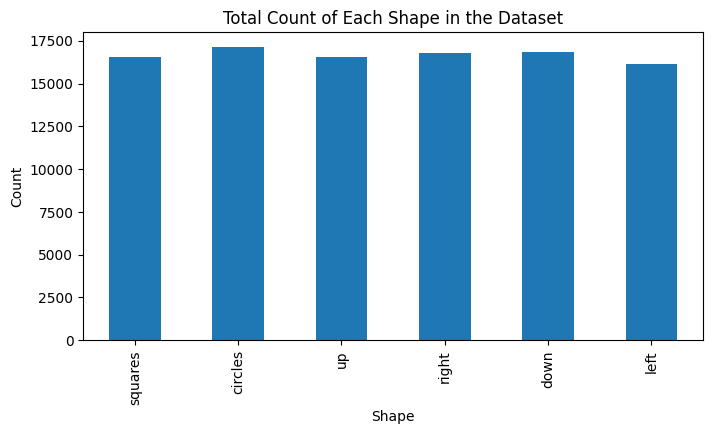

In [5]:
shapes = ['squares','circles','up','right','down','left']

df[shapes].sum().plot(kind='bar', figsize=(8,4))
plt.title('Total Count of Each Shape in the Dataset')
plt.xlabel('Shape')
plt.ylabel('Count')
plt.show()

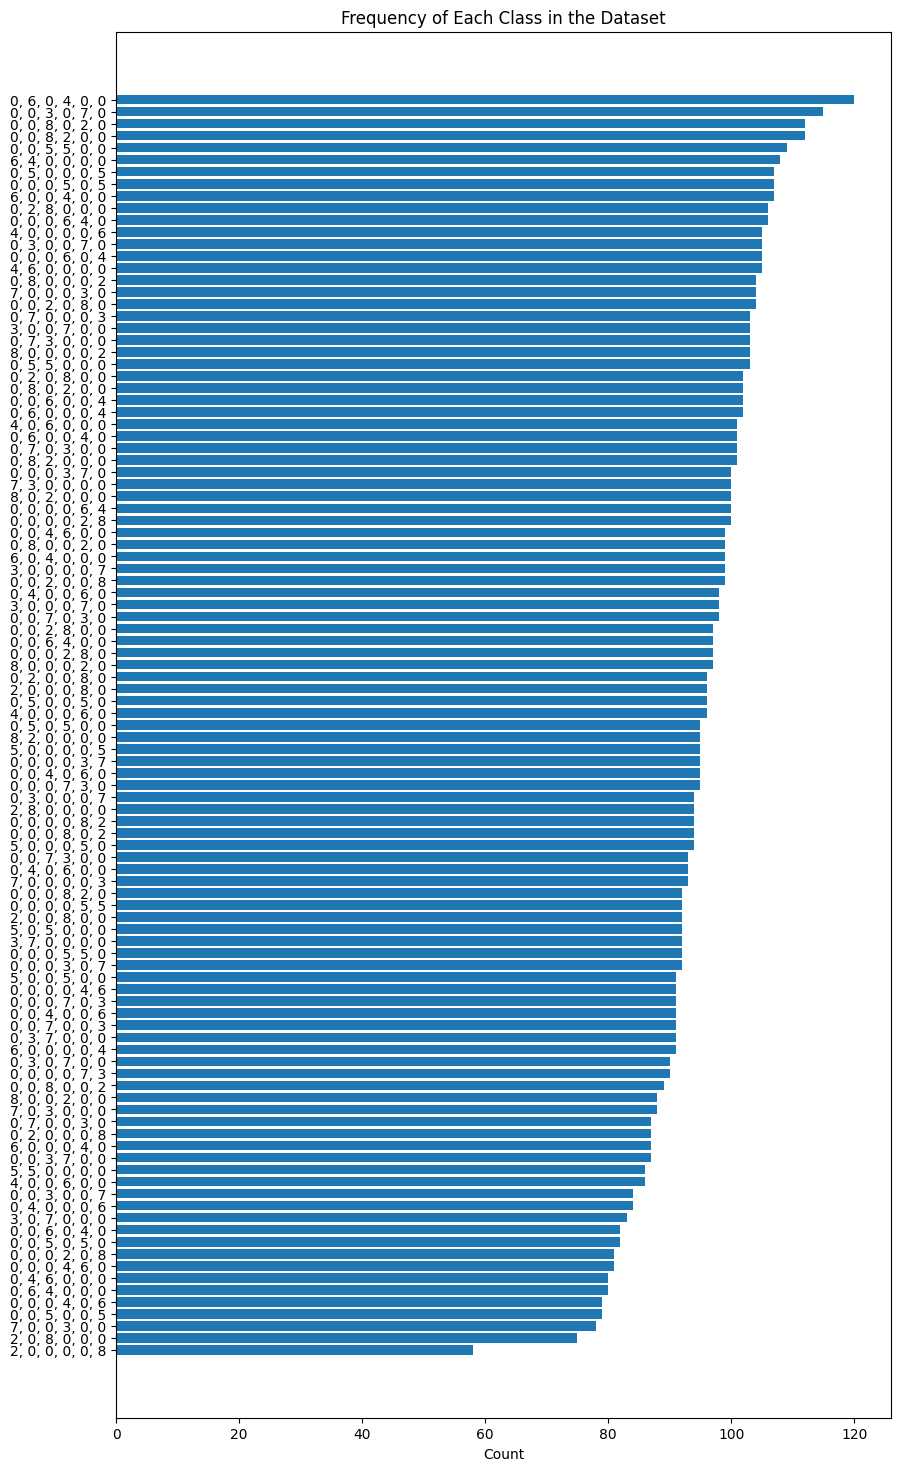

In [6]:
labels = df[shapes].value_counts().reset_index(name='count')
class_str = labels[shapes].astype(str).agg(", ".join, axis=1)

plt.figure(figsize=(10, 18))
plt.barh(class_str, labels['count'])
plt.gca().invert_yaxis()
plt.xlabel("Count")
plt.title("Frequency of Each Class in the Dataset")
plt.show()

In [7]:
all_classes = []
for a, b in combinations(range(6), 2):
    for count_a in range(1, 10):
        count_b = 10 - count_a
        vec = [0, 0, 0, 0, 0, 0]
        vec[a] = count_a
        vec[b] = count_b
        all_classes.append(tuple(vec))

dataset_classes = labels[shapes].apply(tuple, axis=1).value_counts().index
missing_classes = set(all_classes) - set(dataset_classes)
print(f"Number of missing classes: {len(missing_classes)}")
missing_classes

Number of missing classes: 30


{(0, 0, 0, 0, 1, 9),
 (0, 0, 0, 0, 9, 1),
 (0, 0, 0, 1, 0, 9),
 (0, 0, 0, 1, 9, 0),
 (0, 0, 0, 9, 0, 1),
 (0, 0, 0, 9, 1, 0),
 (0, 0, 1, 0, 0, 9),
 (0, 0, 1, 0, 9, 0),
 (0, 0, 1, 9, 0, 0),
 (0, 0, 9, 0, 0, 1),
 (0, 0, 9, 0, 1, 0),
 (0, 0, 9, 1, 0, 0),
 (0, 1, 0, 0, 0, 9),
 (0, 1, 0, 0, 9, 0),
 (0, 1, 0, 9, 0, 0),
 (0, 1, 9, 0, 0, 0),
 (0, 9, 0, 0, 0, 1),
 (0, 9, 0, 0, 1, 0),
 (0, 9, 0, 1, 0, 0),
 (0, 9, 1, 0, 0, 0),
 (1, 0, 0, 0, 0, 9),
 (1, 0, 0, 0, 9, 0),
 (1, 0, 0, 9, 0, 0),
 (1, 0, 9, 0, 0, 0),
 (1, 9, 0, 0, 0, 0),
 (9, 0, 0, 0, 0, 1),
 (9, 0, 0, 0, 1, 0),
 (9, 0, 0, 1, 0, 0),
 (9, 0, 1, 0, 0, 0),
 (9, 1, 0, 0, 0, 0)}

# PyTorch Dataset class

In [8]:

class Augmentator:
    """Applies random augmentations (flip, rotate, brightness/contrast) to images and updates labels."""

    def __init__(self, cnt_to_cls, p_flip=0.5, p_rotate=0.5, p_brightness=0.5, brightness=0.2, contrast=0.2):
        self.cnt_to_cls = cnt_to_cls
        self.p_flip = p_flip
        self.p_rotate = p_rotate
        self.p_brightness = p_brightness
        self.brightness = brightness
        self.contrast = contrast
        self.augmentations = [self.v_flip, self.h_flip, self.l_rotate, self.r_rotate, self.random_brightness_contrast]

    def v_flip(self, image, label_cls, label_cnt):
        """Vertically flip the image and update labels."""
        if torch.rand(1) < self.p_flip:
            image = torch.flip(image, dims=[1])
            label_cnt =  label_cnt[[0, 1, 4, 3, 2, 5]]
            label_cls = torch.tensor(self.cnt_to_cls[tuple(label_cnt.tolist())])
        return image, label_cls, label_cnt

    def h_flip(self, image, label_cls, label_cnt):
        """Horizontally flip the image and update labels."""
        if torch.rand(1) < self.p_flip:
            image = torch.flip(image, dims=[2])
            label_cnt = label_cnt[[0, 1, 2, 5, 4, 3]]
            label_cls = torch.tensor(self.cnt_to_cls[tuple(label_cnt.tolist())])
        return image, label_cls, label_cnt

    def l_rotate(self, image, label_cls, label_cnt):
        """Rotate the image 90 degrees counter-clockwise and update labels."""
        if torch.rand(1) < self.p_rotate:
            image = torch.rot90(image, k=1, dims=[1, 2])
            label_cnt = label_cnt[[0, 1, 3, 4, 5, 2]]
            label_cls = torch.tensor(self.cnt_to_cls[tuple(label_cnt.tolist())])
        return image, label_cls, label_cnt

    def r_rotate(self, image, label_cls, label_cnt):
        """Rotate the image 90 degrees clockwise and update labels."""
        if torch.rand(1) < self.p_rotate:
            image = torch.rot90(image, k=3, dims=[1, 2])
            label_cnt = label_cnt[[0, 1, 5, 2, 3, 4]]
            label_cls = torch.tensor(self.cnt_to_cls[tuple(label_cnt.tolist())])
        return image, label_cls, label_cnt

    def random_brightness_contrast(self, image, label_cls, label_cnt):
        """Randomly adjust brightness and contrast of the image and update labels."""
        if torch.rand(1) < self.p_brightness:
            b = torch.empty(1).uniform_(-self.brightness, self.brightness).item()
            image = image + b
            image = torch.clamp(image, 0, 1)

            c = torch.empty(1).uniform_(1 - self.contrast, 1 + self.contrast).item()
            mean = image.mean(dim=(1,2), keepdim=True)
            image = (image - mean) * c + mean
            image = torch.clamp(image, 0, 1)

        return image, label_cls, label_cnt

    def apply(self, image, label_cls, label_cnt):
        for augmentation in self.augmentations:
            image, label_cls, label_cnt = augmentation(image, label_cls, label_cnt)
        return image, label_cls, label_cnt

In [9]:
class AugmentedDataset(Dataset):
    """Dataset class that applies random augmentations to images and updates labels."""
    def __init__(self, csv_path, img_folder, augment=False):
        df = pd.read_csv(csv_path)
        self.images = []
        self.cnt_labels = []
        self.cls_labels = []
        self.cnt_to_cls = {}
        self.cls_to_cnt = {}
        for pair in combinations(range(6), 2):
            for count_a in range(1, 10):
                count_b = 10 - count_a
                label_cnt = [0] * 6
                label_cnt[pair[0]] = count_a
                label_cnt[pair[1]] = count_b
                self.cnt_to_cls[tuple(label_cnt)] = len(self.cnt_to_cls)
                self.cls_to_cnt[len(self.cls_to_cnt)] = tuple(label_cnt)
        for name in df['name']:
            self.images.append(read_image(f'{img_folder}/{name}')[0:1, :, :] / 255.0)
        for label in df.iloc[:, 1:].values:
            cnt_label = torch.tensor(label)
            self.cnt_labels.append(cnt_label)
            cls_label = torch.tensor(self.cnt_to_cls[tuple(cnt_label.tolist())])
            self.cls_labels.append(cls_label)

        self.images = torch.stack(self.images)
        self.cnt_labels = torch.stack(self.cnt_labels)
        self.cls_labels = torch.tensor(self.cls_labels)

        if augment:
            self.augmentator = Augmentator(self.cnt_to_cls)
        else:
            self.augmentator = None

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img, cls, cnt = self.images[idx], self.cls_labels[idx], self.cnt_labels[idx]
        if self.augmentator:
            img, cls, cnt = self.augmentator.apply(img, cls, cnt)
        return img, cls, cnt

    @property
    def cls_to_cnt_map(self):
        """Return the class to count mapping."""
        return self.cls_to_cnt

    def enable_augmentation(self):
        """Enable augmentation for the dataset."""
        self.augmentator = Augmentator(self.cnt_to_cls)

# Model

In [10]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(1, 8, 3, stride=1, padding=1), nn.ReLU(),
            nn.Conv2d(8, 16, 3, stride=1, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=1, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=1, padding=1), nn.ReLU(),
            nn.Flatten(start_dim=1),
            nn.Linear(64 * 28 * 28, 256), nn.ReLU()
            )
        self.head_cls = nn.Sequential(
            nn.Linear(256, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 135),
            )
        self.head_cnt = nn.Sequential(
            nn.Linear(256, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 6)
            )

    def forward(self, x):
        x = self.backbone(x)
        logits = self.head_cls(x)
        return F.log_softmax(logits, dim=1), self.head_cnt(x)

# Training and Evaluation

In [11]:
def calculate_loss(model, x, y_cls, y_cnt, device, lambda_cls, lambda_cnt):
    """Calculate the loss for the given batch."""
    x, y_cls, y_cnt = x.to(device), y_cls.to(device), y_cnt.to(device)
    y_cls_pred, y_cnt_pred = model(x)
    loss_cls = nn.NLLLoss()(y_cls_pred, y_cls)
    loss_cnt = nn.SmoothL1Loss()(y_cnt_pred, y_cnt)
    loss = lambda_cls * loss_cls + lambda_cnt * loss_cnt
    return loss

In [12]:
class Trainer:
    """Trainer class to handle model training, validation, and evaluation visualization."""
    def __init__(self, model, train_dataset, val_dataset, device, batch_size=64, lr=1e-3, lambda_cls=0.5, lambda_cnt=0.5, patience=10):
        self.device = device
        self.model = model.to(device)
        self.train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        self.val_loader = DataLoader(val_dataset, batch_size=1000)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
        self.lambda_cls = lambda_cls
        self.lambda_cnt = lambda_cnt
        self.patience = patience
        self.cls_to_cnt = train_dataset.dataset.cls_to_cnt_map

    def train_one_epoch(self):
        """Train the model for one epoch."""
        self.model.train()
        total_loss = 0
        for batch in self.train_loader:
            x, y_cls, y_cnt = batch
            x, y_cls, y_cnt = x.to(self.device), y_cls.to(self.device), y_cnt.to(self.device)
            self.optimizer.zero_grad()
            loss = calculate_loss(self.model, x, y_cls, y_cnt, self.device, self.lambda_cls, self.lambda_cnt)
            loss.backward()
            self.optimizer.step()
            total_loss += loss.item() * x.shape[0]

    def validate(self, loader):
        """Validate the model on the given loader."""
        self.model.eval()
        total_loss = 0
        with torch.no_grad():
            for x, y_cls, y_cnt in loader:
                x, y_cls, y_cnt = x.to(self.device), y_cls.to(self.device), y_cnt.to(self.device)
                total_loss += calculate_loss(self.model, x, y_cls, y_cnt, self.device, self.lambda_cls, self.lambda_cnt).item() * x.shape[0]
        return total_loss / len(loader.dataset)

    def plot(self, top1_accuracies, rmses, per_class_rmses, val_losses, train_losses):
        """Plot the training and validation metrics."""
        plt.figure(figsize=(15, 5))
        plt.subplot(1, 2, 1)
        plt.plot(top1_accuracies, label='Top1 accuracy')
        plt.plot(rmses, label='RMSE')
        plt.legend()

        plt.subplot(1, 2, 2)
        for i in range(6):
            plt.plot(per_class_rmses[i], label=f'RMSE class {i}')
        plt.legend()
        plt.show()

        plt.figure(figsize=(15, 5))
        plt.subplot(1, 2, 1)
        plt.plot(val_losses, label='Validation loss')
        plt.plot(train_losses, label='Training loss')
        plt.legend()

        plt.subplot(1, 2, 2)
        ground_truth_cls, _, pred_cls, _ = generate_predictions(self.model, self.val_loader)
        cm = confusion_matrix(ground_truth_cls.cpu(), pred_cls.cpu(), labels=np.arange(135))
        cm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)
        cm = np.nan_to_num(cm)
        sns.heatmap(cm, square=True, xticklabels=False, yticklabels=False)
        plt.title("Confusion Matrix (normalized)")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.show()

        evaluation = evaluate(self.model, self.val_loader, self.cls_to_cnt)
        per_class_final_rmses = [evaluation[f'rmse_class_{i}'] for i in range(6)]
        per_clss_final_maes = [evaluation[f'mae_class_{i}'] for i in range(6)]
        plt.figure(figsize=(15, 5))
        plt.subplot(1, 2, 1)
        plt.bar(range(6), per_class_final_rmses, label='RMSE')
        plt.legend()
        plt.subplot(1, 2, 2)
        plt.bar(range(6), per_clss_final_maes, label='MAE')
        plt.legend()
        plt.show()

        filtered = {k: v for k, v in evaluation.items() if k.startswith("per_pair_acc")}
        labels = [k.split("per_pair_acc_")[1] for k, _ in filtered.items()]
        values = [v for _, v in filtered.items()]

        plt.figure(figsize=(12, 5))
        plt.bar(labels, values)
        plt.ylabel("Accuracy")
        plt.title("Per-pair accuracy")
        plt.show()


    def fit(self, epochs=100):
        """Train the model for a number of epochs with early stopping."""
        best_val_loss = float('inf')
        last_improvement = 0
        top1_accuracies = []
        overall_rmses = []
        per_class_rmses = [[] for _ in range(6)]
        val_losses = []
        train_losses = []
        start = time.time()
        for epoch in range(epochs):
            self.train_one_epoch()
            train_loss = self.validate(self.train_loader)
            val_loss = self.validate(self.val_loader)
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            evaluation = evaluate(self.model, self.val_loader, self.cls_to_cnt)
            top1_accuracies.append(evaluation['top1'])
            overall_rmses.append(evaluation['rmse'])
            for i in range(6):
                per_class_rmses[i].append(evaluation[f'rmse_class_{i}'])
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                last_improvement = epoch
            if epoch - last_improvement >= self.patience:
                print(f'Early stopping at epoch {epoch}')
                break
            if (epoch % 1 == 0):
                print(f'Epoch {epoch}, train loss: {train_loss}, val loss: {val_loss}')
        self.plot(top1_accuracies, overall_rmses, per_class_rmses, val_losses, train_losses)
        print(f'Training time: {time.time() - start}s')
        return best_val_loss



In [13]:
def generate_predictions(model, val_loader):
    """Generate predictions for the validation set."""
    model.eval()
    with torch.no_grad():
        ground_truth_cls = []
        ground_truth_cnt = []
        predictions_cls = []
        predictions_cnt = []
        for batch in val_loader:
            x, y_cls, y_cnt = batch
            x, y_cls, y_cnt = x.to(device), y_cls.to(device), y_cnt.to(device)
            y_cls_pred, y_cnt_pred = model(x)
            _, y_cls_pred = torch.max(y_cls_pred, dim=1)
            predictions_cls.append(y_cls_pred)
            predictions_cnt.append(y_cnt_pred)
            ground_truth_cls.append(y_cls)
            ground_truth_cnt.append(y_cnt)

        ground_truth_cls = torch.cat(ground_truth_cls)
        ground_truth_cnt = torch.cat(ground_truth_cnt)
        predictions_cls = torch.cat(predictions_cls)
        predictions_cnt = torch.cat(predictions_cnt)
    return ground_truth_cls, ground_truth_cnt, predictions_cls, predictions_cnt

def evaluate(model, val_loader, cls_to_cnt):
    """Evaluate the model on the validation set."""
    model.eval()
    with torch.no_grad():
        ground_truth_cls, ground_truth_cnt, predictions_cls, predictions_cnt = generate_predictions(model, val_loader)
        per_pair_len = {}
        per_pair_correct = {}
        for cls_pred, cls_true in zip(predictions_cls, ground_truth_cls):
            unordered_pair = [i for i, x in enumerate(cls_to_cnt[cls_true.item()]) if x != 0]
            per_pair_len[tuple(unordered_pair)] = per_pair_len.get(tuple(unordered_pair), 0) + 1
            if cls_pred == cls_true:
                per_pair_correct[tuple(unordered_pair)] = per_pair_correct.get(tuple(unordered_pair), 0) + 1

        per_pair_acc = {}
        for pair in per_pair_len:
            per_pair_acc[pair] = per_pair_correct.get(pair, 0) / per_pair_len[pair]

        per_class_rmse = {}
        per_class_mae = {}
        for i in range(6):
            rmse = np.sqrt(mean_squared_error(ground_truth_cnt[:, i].cpu(), predictions_cnt[:, i].cpu()))
            mae = mean_absolute_error(ground_truth_cnt[:, i].cpu(), predictions_cnt[:, i].cpu())
            per_class_rmse[i] = rmse
            per_class_mae[i] = mae

        top1 = (predictions_cls == ground_truth_cls).sum().item() / len(ground_truth_cls)
        f1 = f1_score(ground_truth_cls.cpu(), predictions_cls.cpu(), average='macro')
        rmse = np.sqrt(mean_squared_error(ground_truth_cnt.cpu(), predictions_cnt.cpu()))
        mae = mean_absolute_error(ground_truth_cnt.cpu(), predictions_cnt.cpu())
    return (
        {
            'top1': top1,
            'f1': f1,
            'rmse': rmse,
            'mae': mae,
        }
        | {f'rmse_class_{i}': v for i, v in per_class_rmse.items()}
        | {f'mae_class_{i}': v for i, v in per_class_mae.items()}
        | {f'per_pair_acc_{i}': v for i, v in per_pair_acc.items()}
    )


# Running everything

In [14]:
torch.manual_seed(1)
device = torch.accelerator.current_accelerator(check_available=True) or torch.device("cpu")
print(device)

dataset = AugmentedDataset("data/labels.csv", "data", augment=False)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_dataset.dataset.enable_augmentation()

cuda


Epoch 0, train loss: 4.678179453108045, val loss: 4.681387424468994
Epoch 1, train loss: 4.6684156091478135, val loss: 4.670953750610352
Epoch 2, train loss: 4.661687736935086, val loss: 4.661984920501709
Epoch 3, train loss: 4.600840590582954, val loss: 4.60292387008667
Epoch 4, train loss: 4.014885348425971, val loss: 4.014861583709717
Epoch 5, train loss: 3.491733565012614, val loss: 3.5259721279144287
Epoch 6, train loss: 3.026730975680881, val loss: 3.0671796798706055
Epoch 7, train loss: 2.868425456153022, val loss: 2.9106223583221436
Epoch 8, train loss: 2.3749427500830755, val loss: 2.3974950313568115
Epoch 9, train loss: 2.1239292318556044, val loss: 2.2071919441223145
Epoch 10, train loss: 1.9531103032430013, val loss: 1.9894973039627075
Epoch 11, train loss: 1.8323000990549723, val loss: 1.8867138624191284
Epoch 12, train loss: 1.7726499403847589, val loss: 1.8378983736038208
Epoch 13, train loss: 1.58144176419576, val loss: 1.6566106081008911
Epoch 14, train loss: 1.5104505

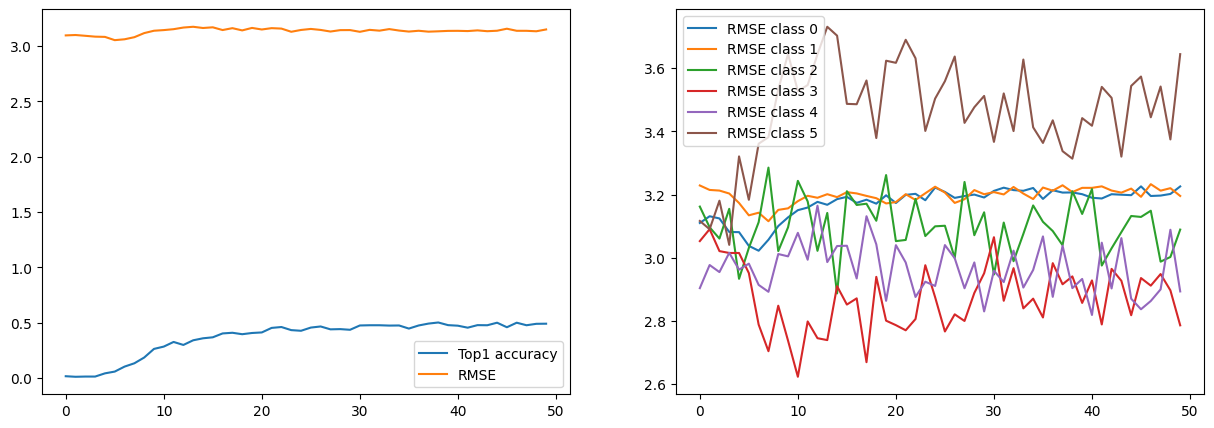

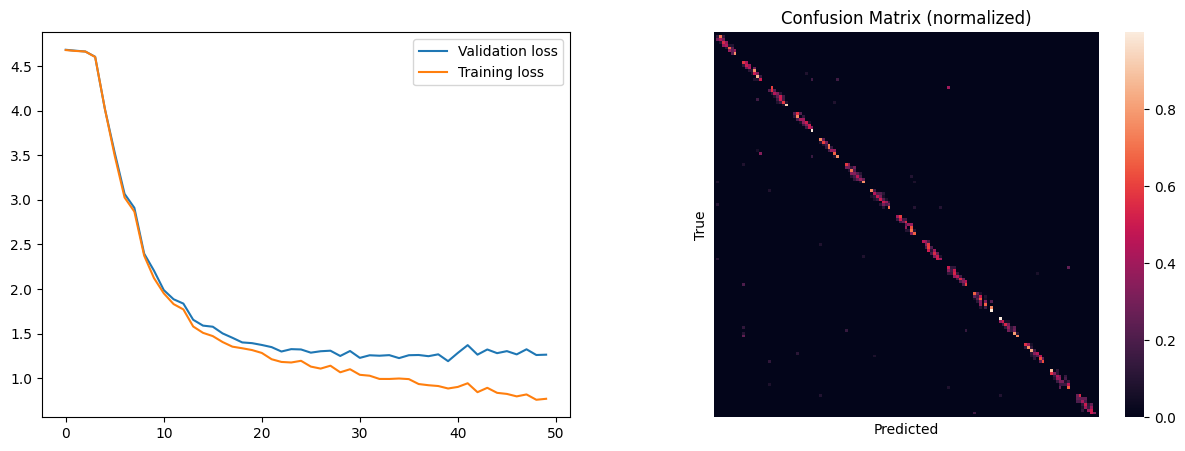

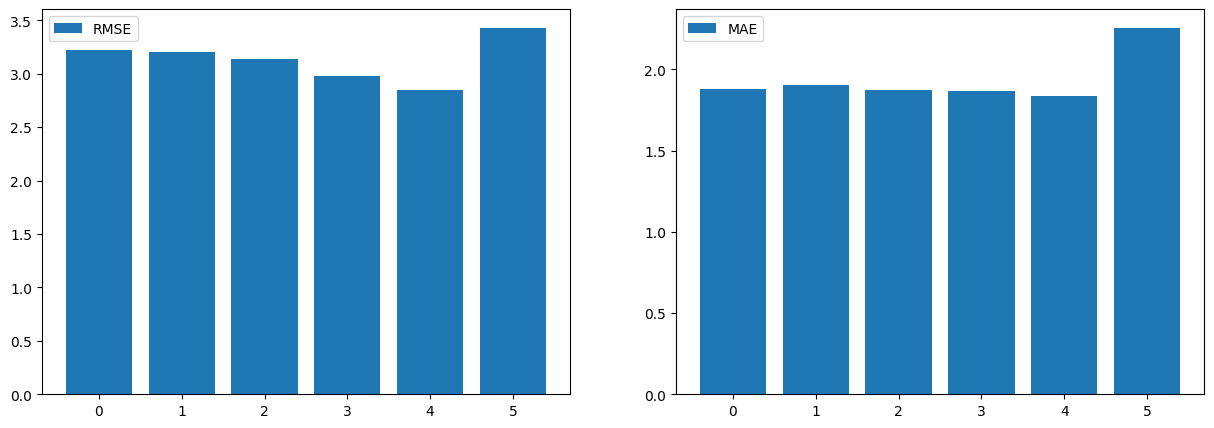

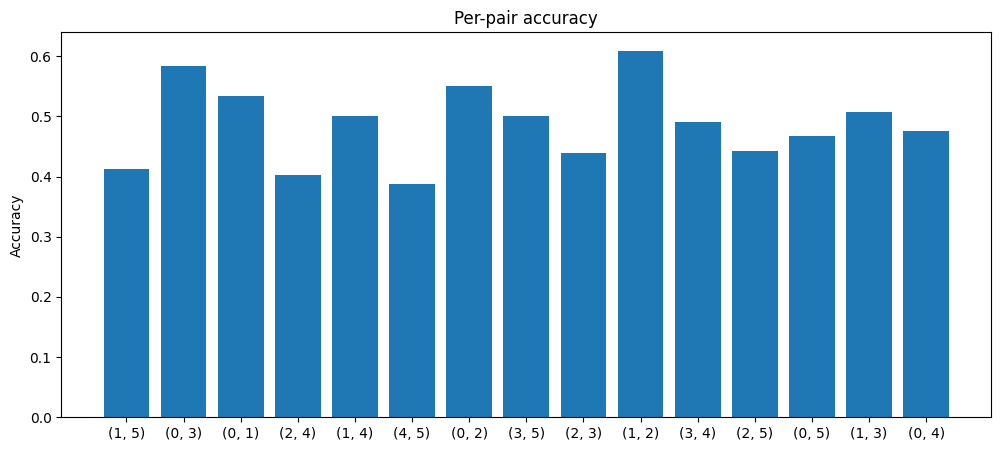

Training time: 307.8749477863312s
{'top1': 0.486, 'f1': 0.4624186758209092, 'rmse': np.float64(3.138963924492207), 'mae': 1.9324338919371364, 'rmse_class_0': np.float64(3.2239620471097905), 'rmse_class_1': np.float64(3.2066759146171755), 'rmse_class_2': np.float64(3.148512991460986), 'rmse_class_3': np.float64(2.982354015512382), 'rmse_class_4': np.float64(2.9336037453449504), 'rmse_class_5': np.float64(3.3208831576927627), 'mae_class_0': 1.8753990201838315, 'mae_class_1': 1.9127476194743067, 'mae_class_2': 1.8682336583584547, 'mae_class_3': 1.876549088858068, 'mae_class_4': 1.8982342833392323, 'mae_class_5': 2.163439681408927, 'per_pair_acc_(1, 3)': 0.4520547945205479, 'per_pair_acc_(0, 3)': 0.4915254237288136, 'per_pair_acc_(0, 1)': 0.5205479452054794, 'per_pair_acc_(3, 5)': 0.375, 'per_pair_acc_(1, 5)': 0.38596491228070173, 'per_pair_acc_(0, 5)': 0.5522388059701493, 'per_pair_acc_(4, 5)': 0.453125, 'per_pair_acc_(1, 2)': 0.5921052631578947, 'per_pair_acc_(0, 4)': 0.6206896551724138,

In [15]:
model_cls = Net()
trainer = Trainer(model_cls, train_dataset, val_dataset, device, lambda_cls=1, lambda_cnt=0)
model_cls_loss = trainer.fit(epochs=100)
print(evaluate(model_cls, DataLoader(val_dataset, batch_size=1000), dataset.cls_to_cnt_map))

Epoch 0, train loss: 1.258502560297648, val loss: 1.2520384788513184
Epoch 1, train loss: 1.041434243520101, val loss: 1.0493459701538086
Epoch 2, train loss: 0.8276396956973606, val loss: 0.8237594366073608
Epoch 3, train loss: 0.6390749078856575, val loss: 0.634562075138092
Epoch 4, train loss: 0.37955532969368827, val loss: 0.39688438177108765
Epoch 5, train loss: 0.3055712090863122, val loss: 0.31127309799194336
Epoch 6, train loss: 0.2809240906238556, val loss: 0.29864102602005005
Epoch 7, train loss: 0.25045814450581866, val loss: 0.2537992596626282
Epoch 8, train loss: 0.28398712460199993, val loss: 0.28987613320350647
Epoch 9, train loss: 0.22588736346032884, val loss: 0.23169058561325073
Epoch 10, train loss: 0.193891597032547, val loss: 0.20678837597370148
Epoch 11, train loss: 0.20616579002804225, val loss: 0.22572417557239532
Epoch 12, train loss: 0.17465812232759265, val loss: 0.19812637567520142
Epoch 13, train loss: 0.18268937938743168, val loss: 0.20226481556892395
Epoc

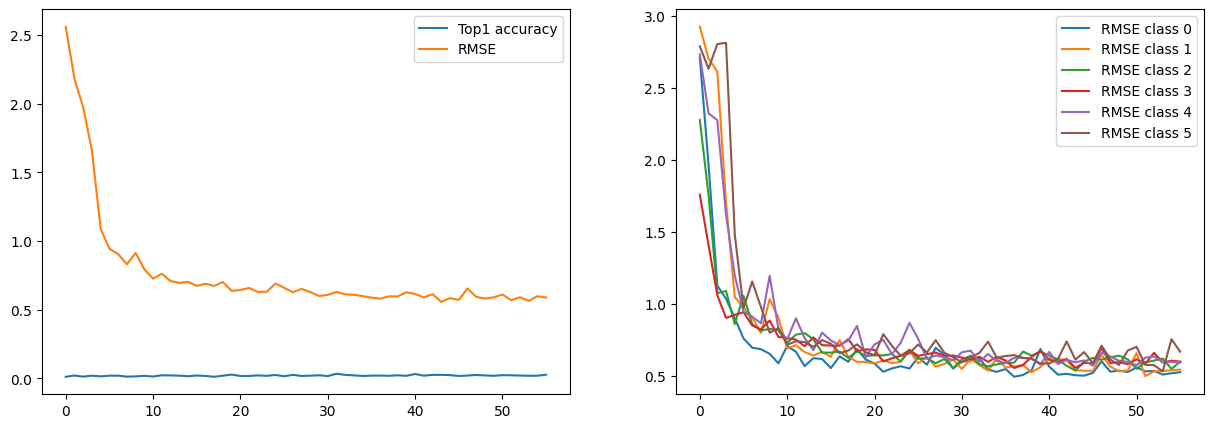

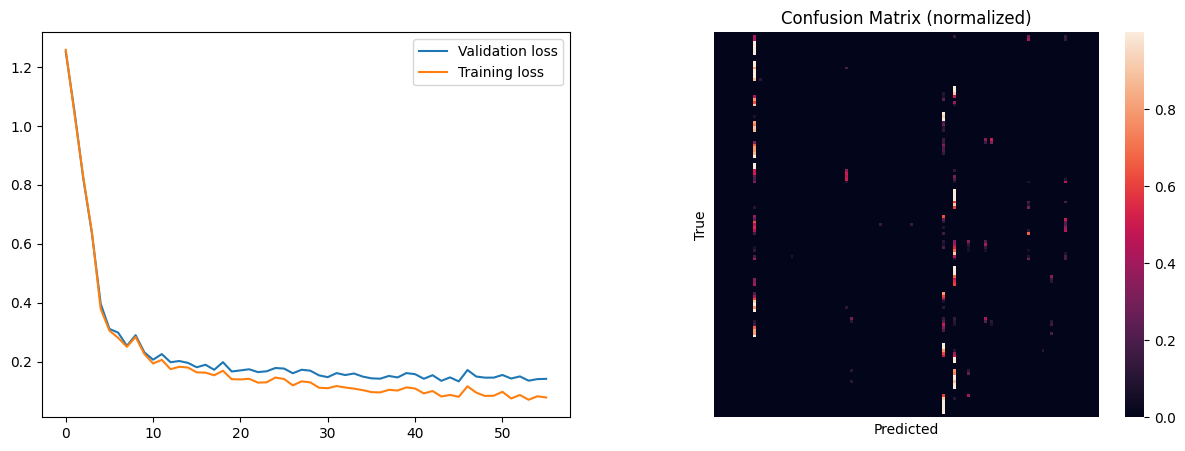

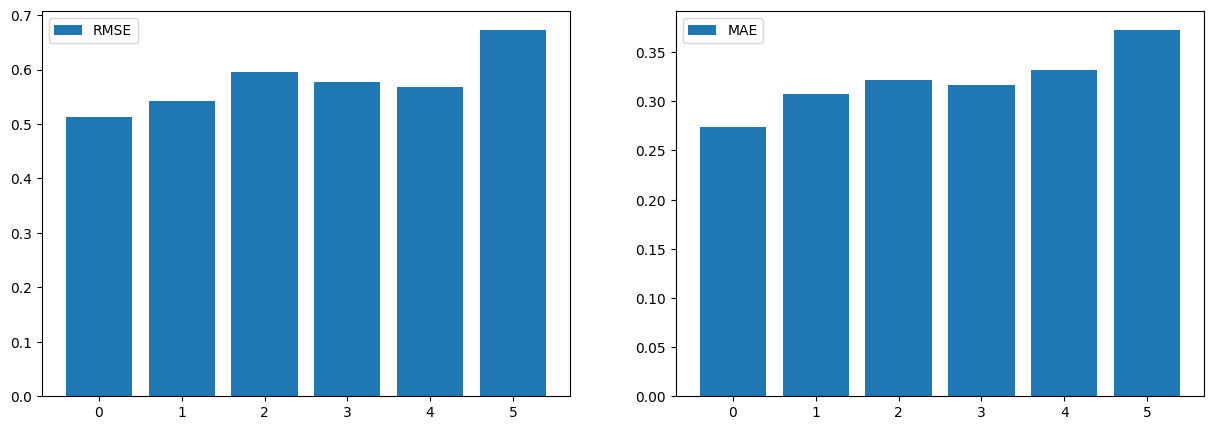

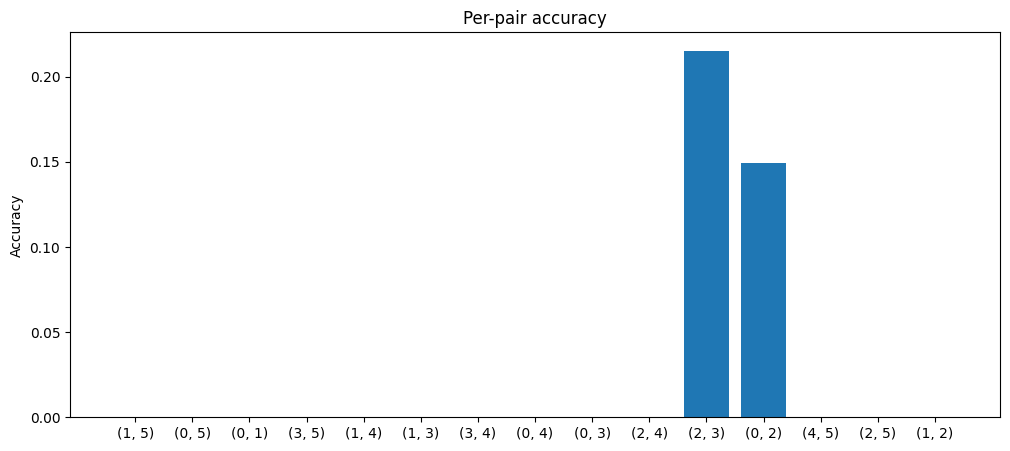

Training time: 346.2066354751587s
{'top1': 0.016, 'f1': 0.0020009823743078275, 'rmse': np.float64(0.5768804343042349), 'mae': 0.3155084664871295, 'rmse_class_0': np.float64(0.489126342903937), 'rmse_class_1': np.float64(0.5368798502852647), 'rmse_class_2': np.float64(0.6196002916221124), 'rmse_class_3': np.float64(0.5617647643861663), 'rmse_class_4': np.float64(0.6214293813414016), 'rmse_class_5': np.float64(0.6193569342914863), 'mae_class_0': 0.2624705955684185, 'mae_class_1': 0.30283884862065313, 'mae_class_2': 0.3284657216370106, 'mae_class_3': 0.30048763769865033, 'mae_class_4': 0.36093986439704895, 'mae_class_5': 0.33784813100099564, 'per_pair_acc_(1, 2)': 0.0, 'per_pair_acc_(0, 4)': 0.0, 'per_pair_acc_(0, 1)': 0.0, 'per_pair_acc_(3, 5)': 0.0, 'per_pair_acc_(1, 5)': 0.0, 'per_pair_acc_(1, 4)': 0.0, 'per_pair_acc_(0, 2)': 0.14035087719298245, 'per_pair_acc_(2, 3)': 0.13559322033898305, 'per_pair_acc_(1, 3)': 0.0, 'per_pair_acc_(0, 5)': 0.0, 'per_pair_acc_(0, 3)': 0.0, 'per_pair_acc

In [16]:
model_cnt = Net()
trainer = Trainer(model_cnt, train_dataset, val_dataset, device, lambda_cls=0, lambda_cnt=1)
model_cnt_loss = trainer.fit(epochs=100)
print(evaluate(model_cnt, DataLoader(val_dataset, batch_size=1000), dataset.cls_to_cnt_map))

Epoch 0, train loss: 16.89388846842448, val loss: 16.868070602416992
Epoch 1, train loss: 11.338240259806316, val loss: 11.175676345825195
Epoch 2, train loss: 7.596088780721028, val loss: 7.651811599731445
Epoch 3, train loss: 6.259872655232748, val loss: 6.346348762512207
Epoch 4, train loss: 4.374209185282389, val loss: 4.452617168426514
Epoch 5, train loss: 4.0962304039001465, val loss: 4.117626190185547
Epoch 6, train loss: 3.5418515290154353, val loss: 3.6843461990356445
Epoch 7, train loss: 3.3339081427256265, val loss: 3.484956741333008
Epoch 8, train loss: 3.3358348274230956, val loss: 3.4527459144592285
Epoch 9, train loss: 3.21347886912028, val loss: 3.3328585624694824
Epoch 10, train loss: 3.06007704755995, val loss: 3.291823625564575
Epoch 11, train loss: 2.970791451136271, val loss: 3.2088589668273926
Epoch 12, train loss: 2.9436711887783473, val loss: 3.1887054443359375
Epoch 13, train loss: 3.0854700741238066, val loss: 3.366586685180664
Epoch 14, train loss: 2.86768370

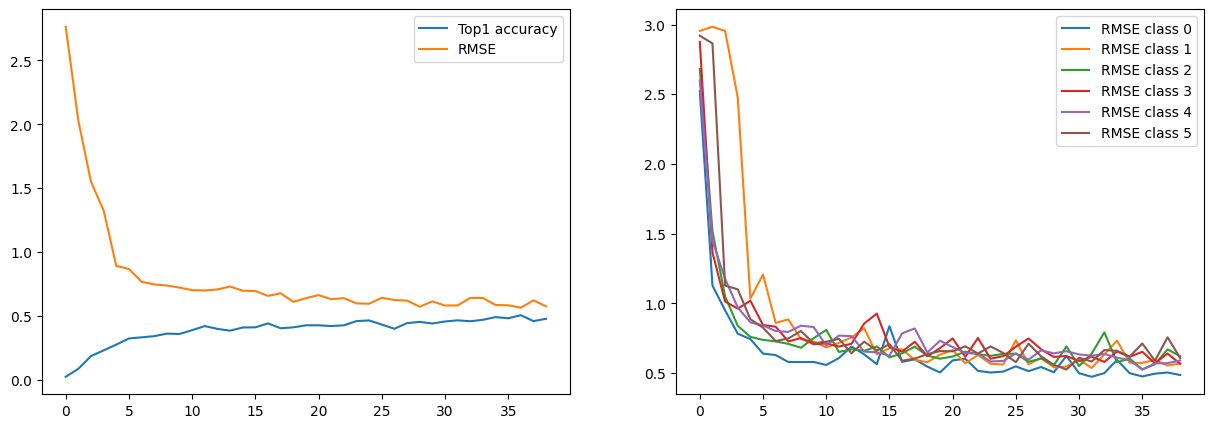

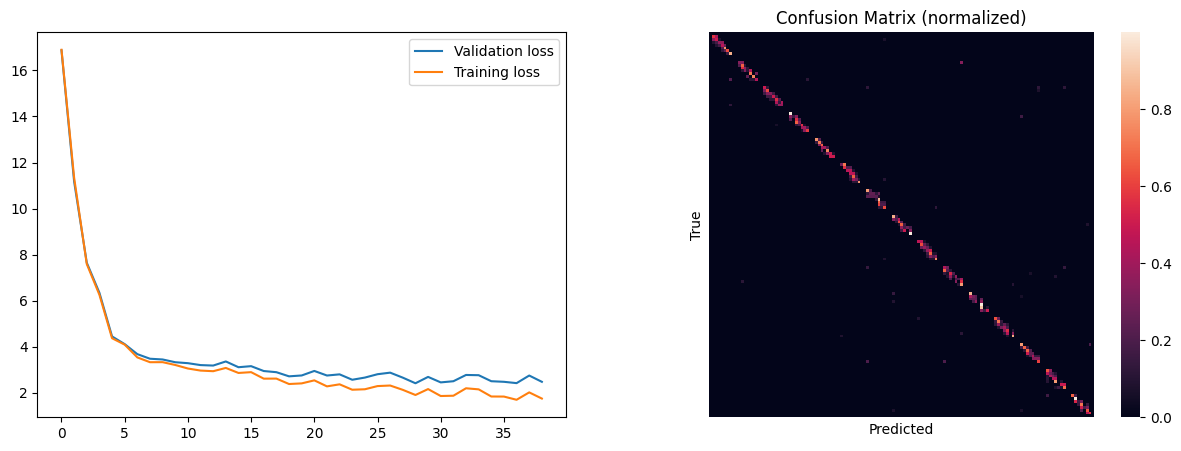

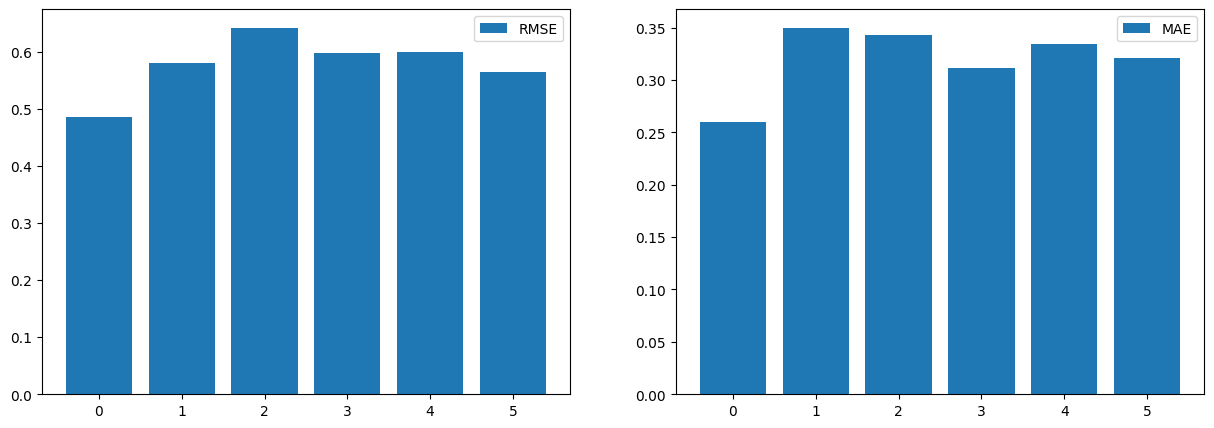

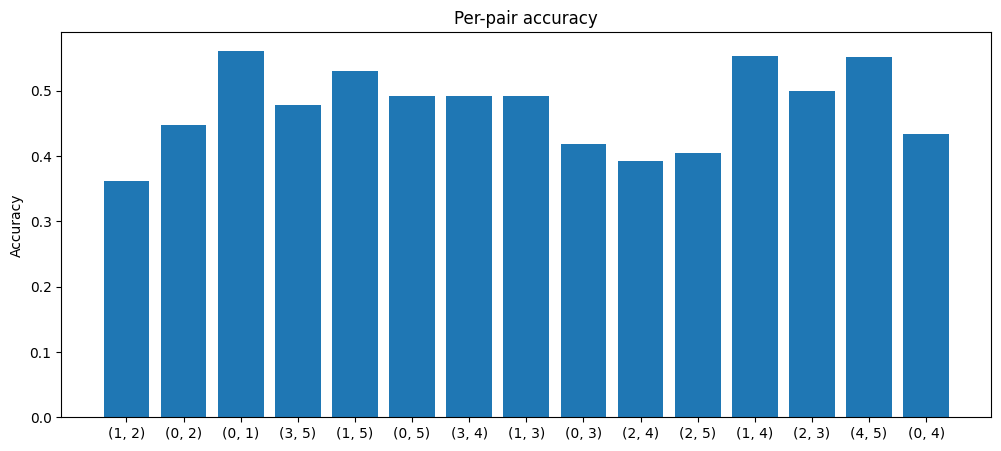

Training time: 240.85926222801208s
{'top1': 0.449, 'f1': 0.4281682098899288, 'rmse': np.float64(0.5681937530977932), 'mae': 0.31407047438124813, 'rmse_class_0': np.float64(0.4946681356735717), 'rmse_class_1': np.float64(0.5640326196414568), 'rmse_class_2': np.float64(0.6279707486784871), 'rmse_class_3': np.float64(0.5893439727846729), 'rmse_class_4': np.float64(0.5699097635544315), 'rmse_class_5': np.float64(0.5547655070727296), 'mae_class_0': 0.2689645276367664, 'mae_class_1': 0.3403499298095703, 'mae_class_2': 0.32137232849001884, 'mae_class_3': 0.3241884486079216, 'mae_class_4': 0.31705075269937516, 'mae_class_5': 0.3124968590438366, 'per_pair_acc_(1, 3)': 0.359375, 'per_pair_acc_(0, 3)': 0.5, 'per_pair_acc_(0, 1)': 0.5342465753424658, 'per_pair_acc_(3, 5)': 0.40298507462686567, 'per_pair_acc_(3, 4)': 0.527027027027027, 'per_pair_acc_(1, 2)': 0.3968253968253968, 'per_pair_acc_(0, 5)': 0.38571428571428573, 'per_pair_acc_(0, 2)': 0.47619047619047616, 'per_pair_acc_(2, 4)': 0.278481012

In [17]:
lambda_cnt = model_cls_loss / model_cnt_loss
model_multitask = Net()
trainer = Trainer(model_multitask, train_dataset, val_dataset, device, lambda_cls=1, lambda_cnt=lambda_cnt)
trainer.fit(epochs=100)
print(evaluate(model_multitask, DataLoader(val_dataset, batch_size=1000), dataset.cls_to_cnt_map))